<a href="https://colab.research.google.com/github/Shorovpaul/Data_Testing/blob/main/Cleaned_dataset_Thyroid1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

In [10]:
import pandas as pd

data = pd.read_csv("cleaned_dataset_Thyroid1.csv")

print(data.shape)
# Step 1: Rename the column
data.rename(columns={'binaryClass': 'Class'}, inplace=True)

# Step 2: Verify it worked
print(data.columns.tolist())

# Step 3: Now use it
print(data['Class'].value_counts())

(3771, 26)
['age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'Class']
Class
0    3480
1     291
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(y_train_bal.value_counts())

Class
0    2783
1    2783
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

In [15]:
from sklearn.metrics import average_precision_score

model_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:,1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

print(model_scores)

{'LR': np.float64(0.8912570344497875), 'RF': np.float64(0.997172441242144), 'GB': np.float64(0.9510227225652094), 'KNN': np.float64(0.34030869599383917), 'SVM': np.float64(0.7403698169597202), 'XGB': np.float64(0.9731035677918211)}


In [16]:
selected_models = {
    name:model for name,model in trained_models.items()
    if model_scores[name] > 0.70
}

In [17]:
import shap
import numpy as np

explanations = {}

for name, model in selected_models.items():
    if name == "SVM":
        # For SVC, shap.Explainer requires the predict_proba method
        explainer = shap.Explainer(model.predict_proba, X_train_bal[:1000])
        shap_values = explainer(X_train_bal[:1000])
        # SHAP values for multi-output are usually (num_samples, num_features, num_classes),
        # so we select for class 1 and then average over samples.
        importance = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
    else:
        explainer = shap.Explainer(model, X_train_bal[:1000])
        shap_values = explainer(X_train_bal[:1000])

        # Check if shap_values.values has a third dimension (num_classes).
        # This typically happens for some classifiers (e.g., RandomForestClassifier, GradientBoostingClassifier)
        # when shap.Explainer is used, and it interprets them as multi-output.
        if shap_values.values.ndim == 3: # If shape is (num_samples, num_features, num_classes)
            # Select SHAP values for the positive class (class 1)
            importance = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
        else: # If shape is (num_samples, num_features)
            importance = np.abs(shap_values.values).mean(axis=0)

    explanations[name] = importance

PermutationExplainer explainer: 1001it [52:18,  3.14s/it]


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

diversity_scores = {}

names = list(explanations.keys())

for i in range(len(names)):
    for j in range(i+1, len(names)):

        sim = cosine_similarity(
            explanations[names[i]].reshape(1,-1),
            explanations[names[j]].reshape(1,-1)
        )[0][0]

        diversity = 1 - sim

        diversity_scores[(names[i],names[j])] = diversity

print(diversity_scores)

{('LR', 'RF'): np.float64(0.2406950115434583), ('LR', 'GB'): np.float64(0.43542476262184726), ('LR', 'SVM'): np.float64(0.16124533762193483), ('LR', 'XGB'): np.float64(0.2569033040234775), ('RF', 'GB'): np.float64(0.2328345796767769), ('RF', 'SVM'): np.float64(0.3509842379127882), ('RF', 'XGB'): np.float64(0.011707487339269185), ('GB', 'SVM'): np.float64(0.4073659972786495), ('GB', 'XGB'): np.float64(0.21586072768565845), ('SVM', 'XGB'): np.float64(0.3271215916058172)}


In [22]:
final_scores = {}

for name in selected_models:

    performance = model_scores[name]
    stability = stability_scores[name]

    diversity = np.mean([
        v for k,v in diversity_scores.items() if name in k
    ])

    score = (
        0.5 * performance +
        0.3 * stability +
        0.2 * diversity
    )

    final_scores[name] = score

print(final_scores)

{'LR': np.float64(0.7403419380154296), 'RF': np.float64(0.7803972864446866), 'GB': np.float64(0.7800856646457514), 'SVM': np.float64(0.6725207667008195), 'XGB': np.float64(0.7671314394286217)}


In [23]:
top_models = sorted(final_scores, key=final_scores.get, reverse=True)[:3]

In [24]:
from sklearn.ensemble import StackingClassifier

estimators = [(name, selected_models[name]) for name in top_models]

meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

stack.fit(X_train_bal, y_train_bal)

StackingClassifier(estimators=[('RF', RandomForestClassifier(n_estimators=200)),
                               ('GB', GradientBoostingClassifier()),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=Non...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())

In [25]:
probs = stack.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import average_precision_score

auprc = average_precision_score(y_test, probs)

print("Stacked AUPRC:", auprc)

Stacked AUPRC: 0.9946292017876708


PermutationExplainer explainer: 201it [01:39,  1.84it/s]
/tmp/ipykernel_8564/2910947139.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values)


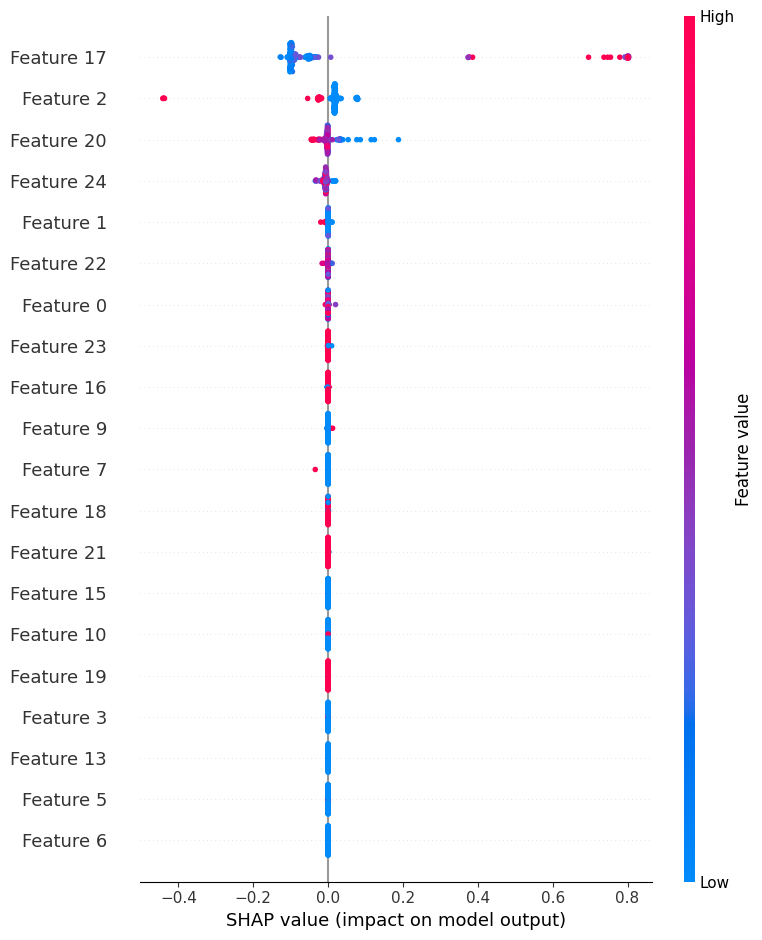

In [27]:
explainer = shap.Explainer(lambda x: stack.predict_proba(x)[:, 1], X_train_bal[:1000])
shap_values = explainer(X_test_scaled[:200])

shap.summary_plot(shap_values)